# ITD224 Applied Data Science Project

Name: Tan Puey Leng

Admin number: 5888749K

Import Libraries

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Data Inspection

Load the dataset and create 'attrition_df' dataframe

In [ ]:
# Read the excel file 'HR_Employee_Attrition_dataset.csv' into a dataframe called 'attrition_df'
attrition_df = pd.read_excel('HR_Employee_Attrition_Dataset.xlsx')

In [ ]:
attrition_df.head()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,Yes,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,...,1,80,0,8,0,1,6,4,0,5
1,2,No,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,...,4,80,1,10,3,3,10,7,1,7
2,3,Yes,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,...,2,80,0,7,3,3,0,0,0,0
3,4,No,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,...,3,80,0,8,3,3,8,7,3,0
4,5,No,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
print(attrition_df.shape)

(2940, 34)


In [ ]:
# Check missing values
attrition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            2940 non-null   int64 
 1   Attrition                 2940 non-null   object
 2   Age                       2940 non-null   int64 
 3   BusinessTravel            2940 non-null   object
 4   DailyRate                 2940 non-null   int64 
 5   Department                2940 non-null   object
 6   DistanceFromHome          2940 non-null   int64 
 7   Education                 2940 non-null   int64 
 8   EducationField            2940 non-null   object
 9   EnvironmentSatisfaction   2940 non-null   int64 
 10  Gender                    2940 non-null   object
 11  HourlyRate                2940 non-null   int64 
 12  JobInvolvement            2940 non-null   int64 
 13  JobLevel                  2940 non-null   int64 
 14  JobRole                 

There are no missing values in this dataset.

In [ ]:
# Check duplicates
attrition_df['EmployeeNumber'].nunique()

2940

2940 unique Employee Numbers in 2940 rows of data. No duplicates found.

In [ ]:
# Check for impossible values such as negative values in any of the columns or out-of-bound values for ordinal variables (e.g. 'JobSatisfaction'>4)
attrition_df.describe().T

,count,mean,std,min,25%,50%,75%,max
EmployeeNumber,2940.0,1470.500000,848.849221,1.0,735.75,1470.5,2205.25,2940.0
Age,2940.0,36.923810,9.133819,18.0,30.00,36.0,43.00,60.0
DailyRate,2940.0,802.485714,403.440447,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,2940.0,9.192517,8.105485,1.0,2.00,7.0,14.00,29.0
Education,2940.0,2.912925,1.023991,1.0,2.00,3.0,4.00,5.0
EnvironmentSatisfaction,2940.0,2.721769,1.092896,1.0,2.00,3.0,4.00,4.0
HourlyRate,2940.0,65.891156,20.325969,30.0,48.00,66.0,84.00,100.0
JobInvolvement,2940.0,2.729932,0.711440,1.0,2.00,3.0,3.00,4.0
JobLevel,2940.0,2.063946,1.106752,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,2940.0,2.728571,1.102658,1.0,2.00,3.0,4.00,4.0


*   StandardHours is 80 for all entries. It is a zero-variance feature therefore this column is not useful for the model and should be removed.

*   No impossible values in all columns based on their minimum and maximum values.

*   All ordinal variables contain no out-of-bounds entries

In [ ]:
# Check column names
attrition_df.columns

Index(['EmployeeNumber', 'Attrition', 'Age', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
# Get a list of all column names where the data type is 'object'
objectcols = attrition_df.select_dtypes(include=['object']).columns.tolist()

# Check for all unique values in each column
for col in objectcols:
  print([col],":",attrition_df[col].unique())

['Attrition'] : ['Yes' 'No']
['BusinessTravel'] : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
['Department'] : ['Sales' 'Research & Development' 'Human Resources']
['EducationField'] : ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
['Gender'] : ['Female' 'Male']
['JobRole'] : ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
['MaritalStatus'] : ['Single' 'Married' 'Divorced']
['Over18'] : ['Y']
['OverTime'] : ['Yes' 'No']




*   Entries in 'Attrition' and 'Overtime' are 'Yes' or 'No'. Binary encoding will be done as strings must be converted into numerical formats for machine learning.

*   Entries in 'BusinessTravel' are 'Non-Travel', 'Travel_Rarely' and 'Travel_Frequently'. There is an escalating relationship in the data where 'Non-Travel' is less than 'Travel_Rarely', which is less than 'Travel_Frequently'. Ordinal encoding will be performed on 'BusinessTravel' where entries will be manually mapped into a 0 to 2 number scale.

*   All entries in 'Over18' is 'Y'. The column should be removed as it is a zero-variance feature which provides no predictive power.

*   There are no spelling error or different uppercase or lowercase variations of the same word that need to be replaced in all catergorical columns.






# Data Cleaning

**Remove Irrelevant Columns**

In [ ]:
# Remove irrelevant columns and create 'attrition' dataframe
attrition = attrition_df.drop(columns=['EmployeeNumber','DailyRate','HourlyRate','MonthlyRate','Over18','StandardHours'])

print(attrition.shape)

(2940, 28)


# Exploratory Data Analysis

**Target Variable**

/tmp/ipykernel_6415/2930547588.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


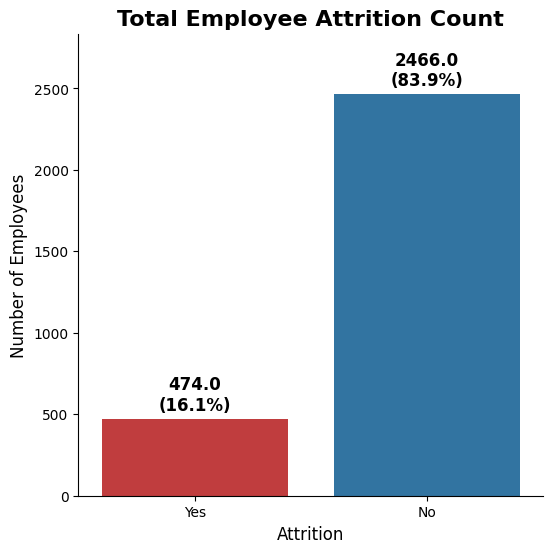

In [ ]:
# Plot bar chart of target variable
plt.figure(figsize=(6, 6))
attrition_colors = {'Yes': '#d62728', 'No': '#1f77b4'}

# Create the countplot and assign it to a variable 'ax'
ax = sns.countplot(
    data=attrition_df,
    x='Attrition',
    palette=attrition_colors
)

max_val = attrition_df['Attrition'].value_counts().max()
ax.set_ylim(0, max_val * 1.15)

# Calculate total number of rows (employees) in the dataset
total_employees = len(attrition_df)

# Add the custom labels (count + percentage) on top of the bars
for container in ax.containers:
    custom_labels = [f"{bar.get_height()}\n({(bar.get_height() / total_employees) * 100:.1f}%)" for bar in container]
    ax.bar_label(container, labels=custom_labels, fontsize=12, padding=3, fontweight='bold')

plt.title('Total Employee Attrition Count', fontsize=16, fontweight='bold')
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)

sns.despine()

plt.show()

The target variable showed a significant class imbalance with 16.1% of the employees attrited and 83.9% retained. To prevent the machine learning models from developing a bias toward the majority class, the training set should be balanced prior to model training.

**Numerical Features**

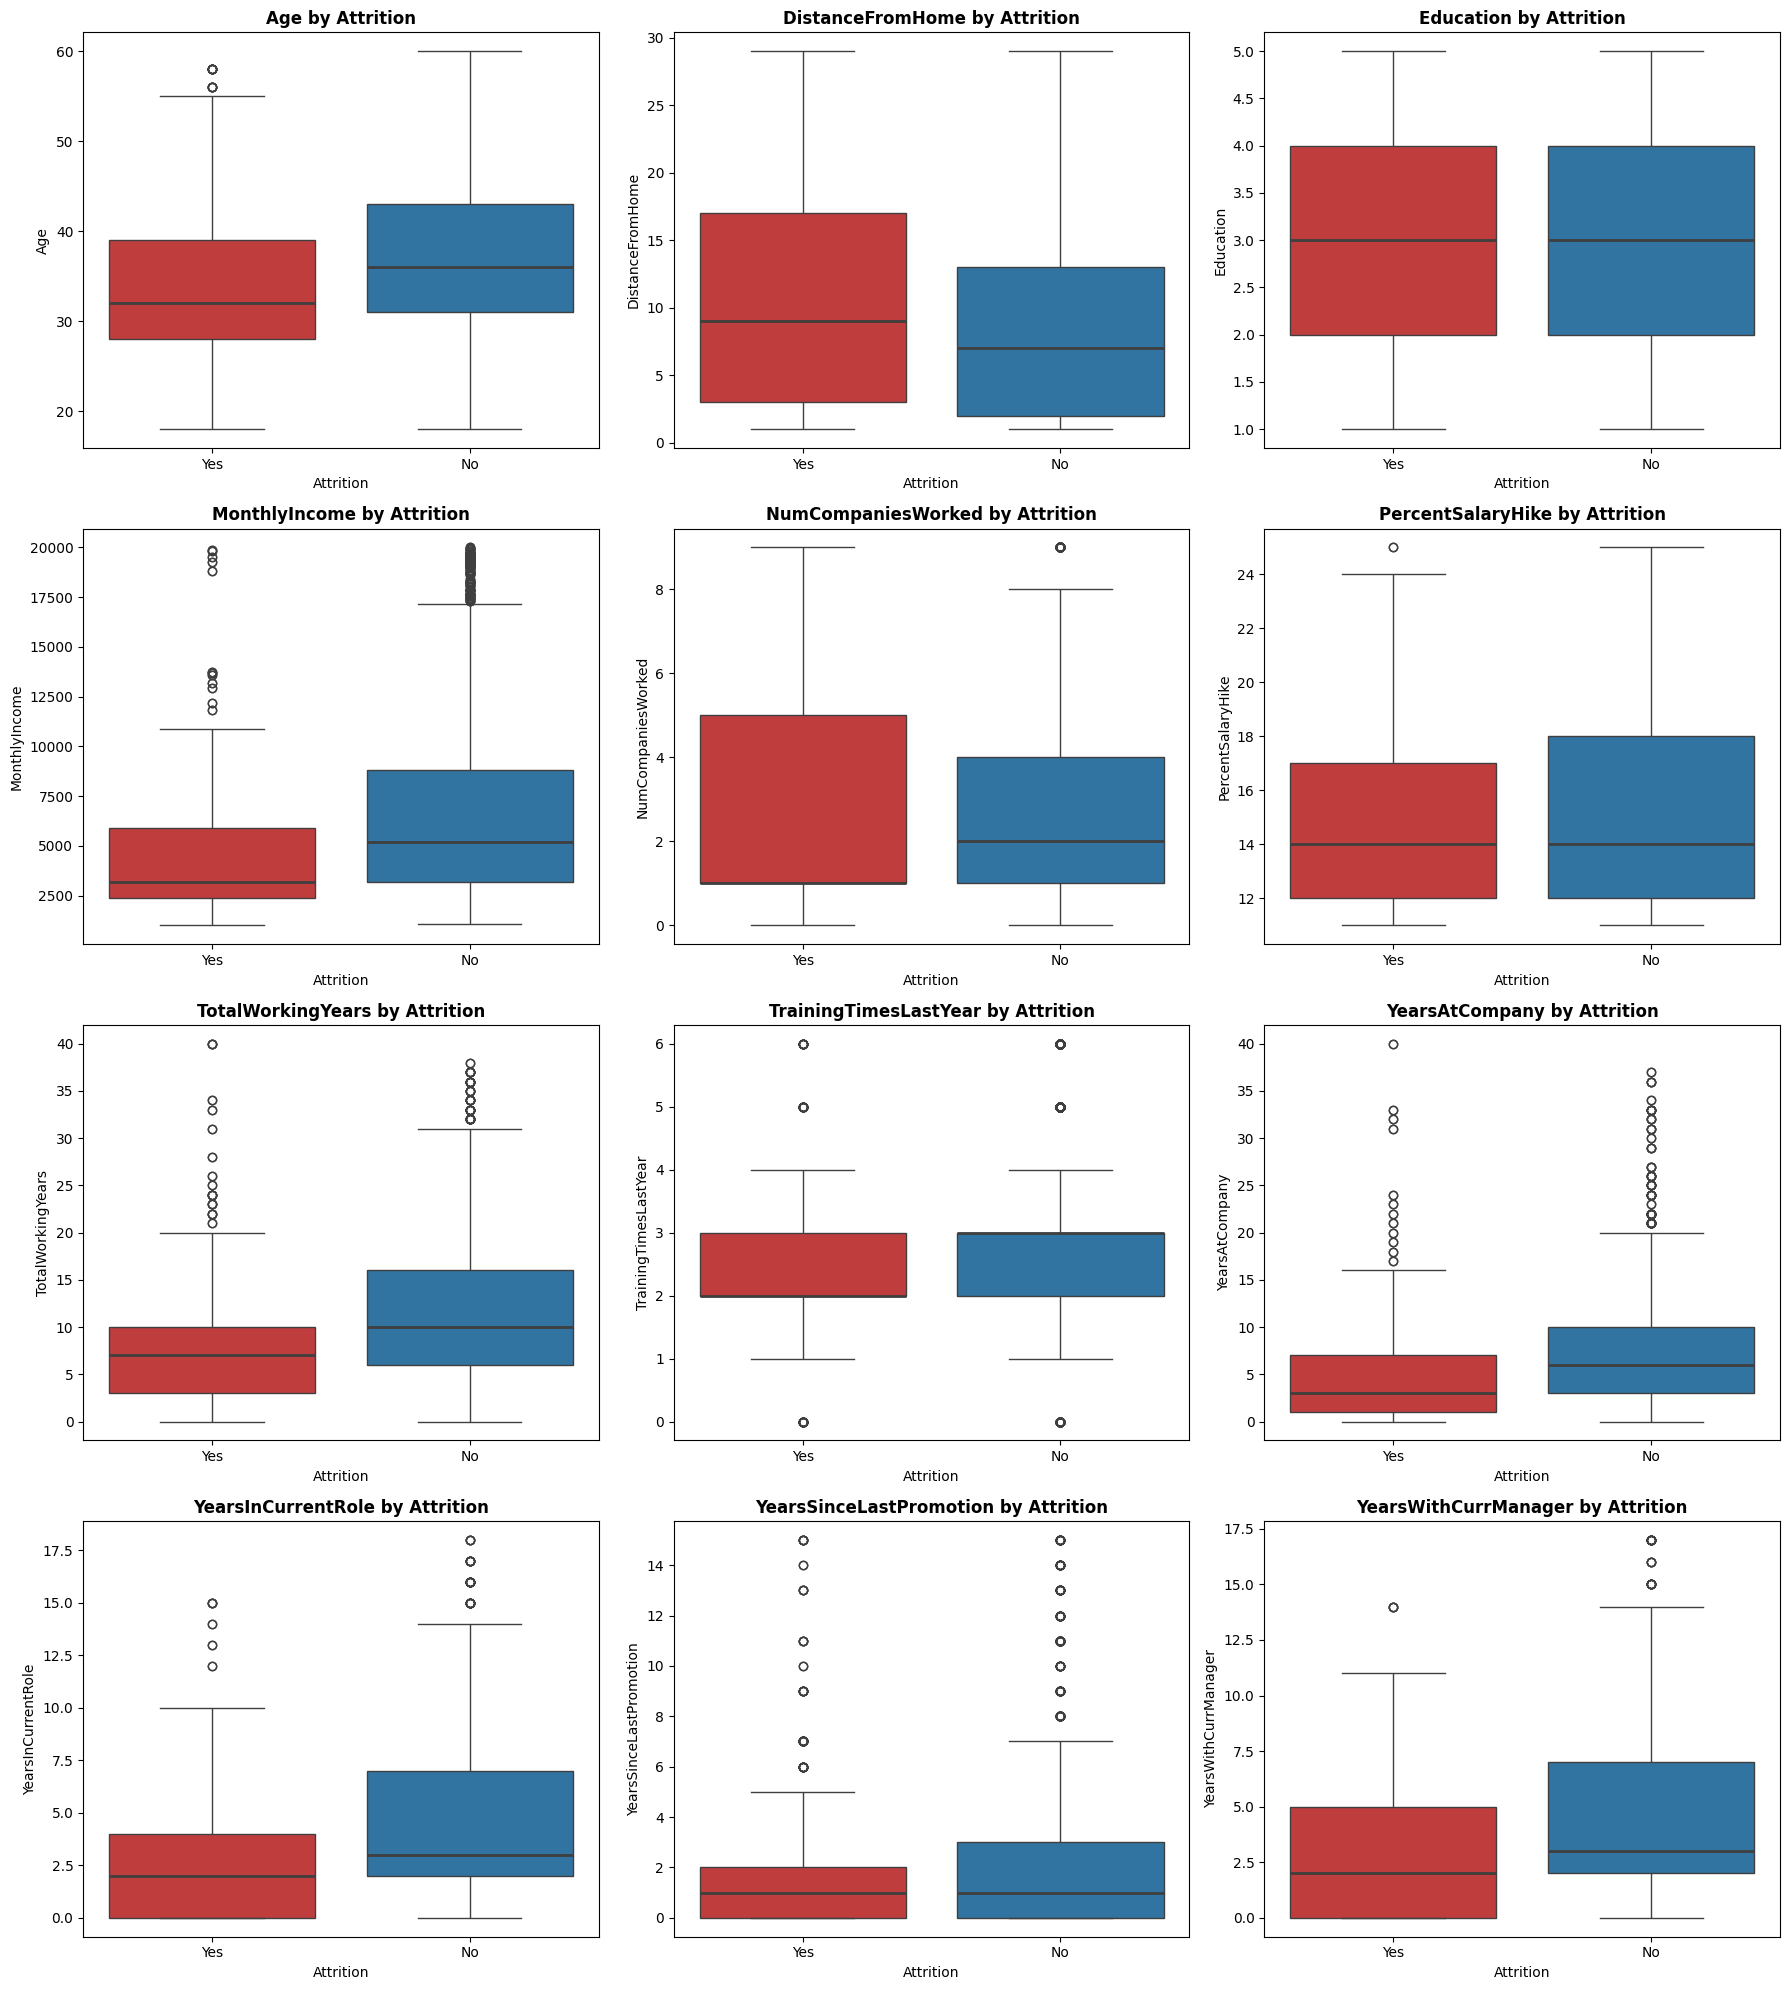

In [ ]:
# Extract numerical columns
num_cols = attrition.select_dtypes(include=['number', 'float', 'int']).columns

# Define and filter the columns to exclude
cols_to_exclude = [
    'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
    'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
    'StockOptionLevel', 'WorkLifeBalance'
]

num_cols = [col for col in num_cols if col not in cols_to_exclude]

# Set up grid layout
cols_per_row = 3
num_rows = math.ceil(len(num_cols) / cols_per_row)
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(18, 5 * num_rows))
axes = axes.flatten()

# Plot vertical boxplots split by Attrition
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=attrition,
        x='Attrition',
        y=col,
        hue='Attrition',
        ax=axes[i],
        palette=['#d62728', '#1f77b4'],
        medianprops={'linewidth': 2}
    )

    axes[i].set_title(f'{col} by Attrition', fontweight='bold')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Observations
*   'Age', 'MonthlyIncome', 'NumCompaniesWorked', 'TotalWorkingYears', 'TrainingTimesLastYear','YearsAtCompany', 'YearsInCurrentRole' and 'YearsWithCurrManager': Attrited group had a lower median value than the retained group.

*   'DistanceFromHome': Attrited group had a higher median value than the retained group.

*   'Education', 'PercentSalaryHike' and 'YearsSinceLastPromotion': No difference in the median value of attrited and retained group.

**Ordinal Features**

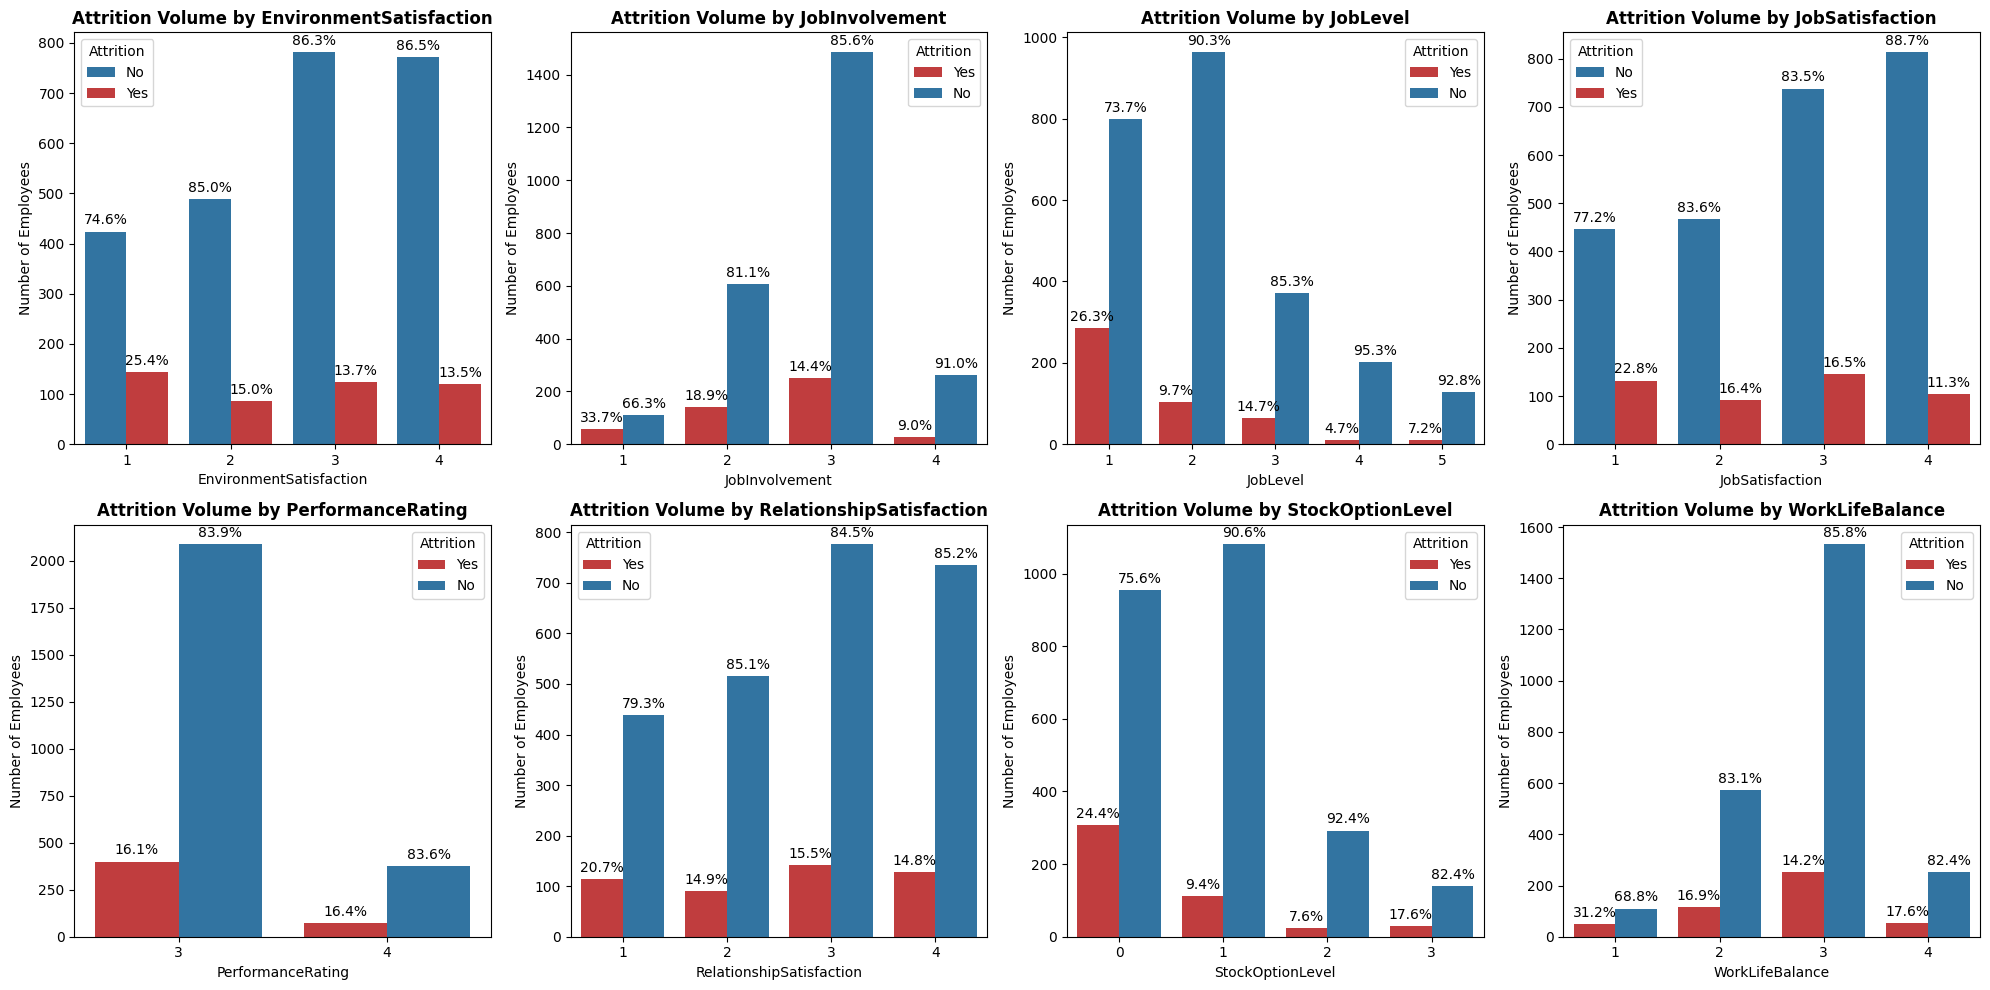

In [ ]:
# Set up the matplotlib figure
plt.figure(figsize=(20, 10))

attrition_colors = {'Yes': '#d62728', 'No': '#1f77b4'}

for i, col in enumerate(cols_to_exclude, 1):
    plt.subplot(2, 4, i)

    ax = sns.countplot(
        data=attrition_df,
        x=col,
        hue='Attrition',
        palette=attrition_colors
    )

    # Calculate within-group percentages
    group_totals = {}
    for p in ax.patches:
        tick_position = int(round(p.get_x() + p.get_width() / 2.0))
        if not pd.isna(p.get_height()):
            group_totals[tick_position] = group_totals.get(tick_position, 0) + p.get_height()

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            tick_position = int(round(p.get_x() + p.get_width() / 2.0))
            local_total = group_totals[tick_position]

            # Calculate the percentage relative to the local group total
            percentage = f'{100 * height / local_total:.1f}%'

            ax.annotate(percentage,
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=10, color='black',
                        xytext=(0, 3),
                        textcoords='offset points')

    plt.title(f'Attrition Volume by {col}', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Employees')

plt.tight_layout()
plt.show()

Observations
*   'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'RelationshipSatisfaction' and 'WorkLifeBalance': Higher proportion of employees that indicated "1" attrited as compared to the other scores.

*   'JobLevel' and 'StockOptionLevel': Majority of attrited employees had the lowest level. Higher proportion of employees in the lowest level attrited as compared to the other levels.

*   'PerformanceRating': No trend observed. Employees were given a rating of either 3 or 4 and majority were given 3. There was little variance in the data.

**Categorical Features**

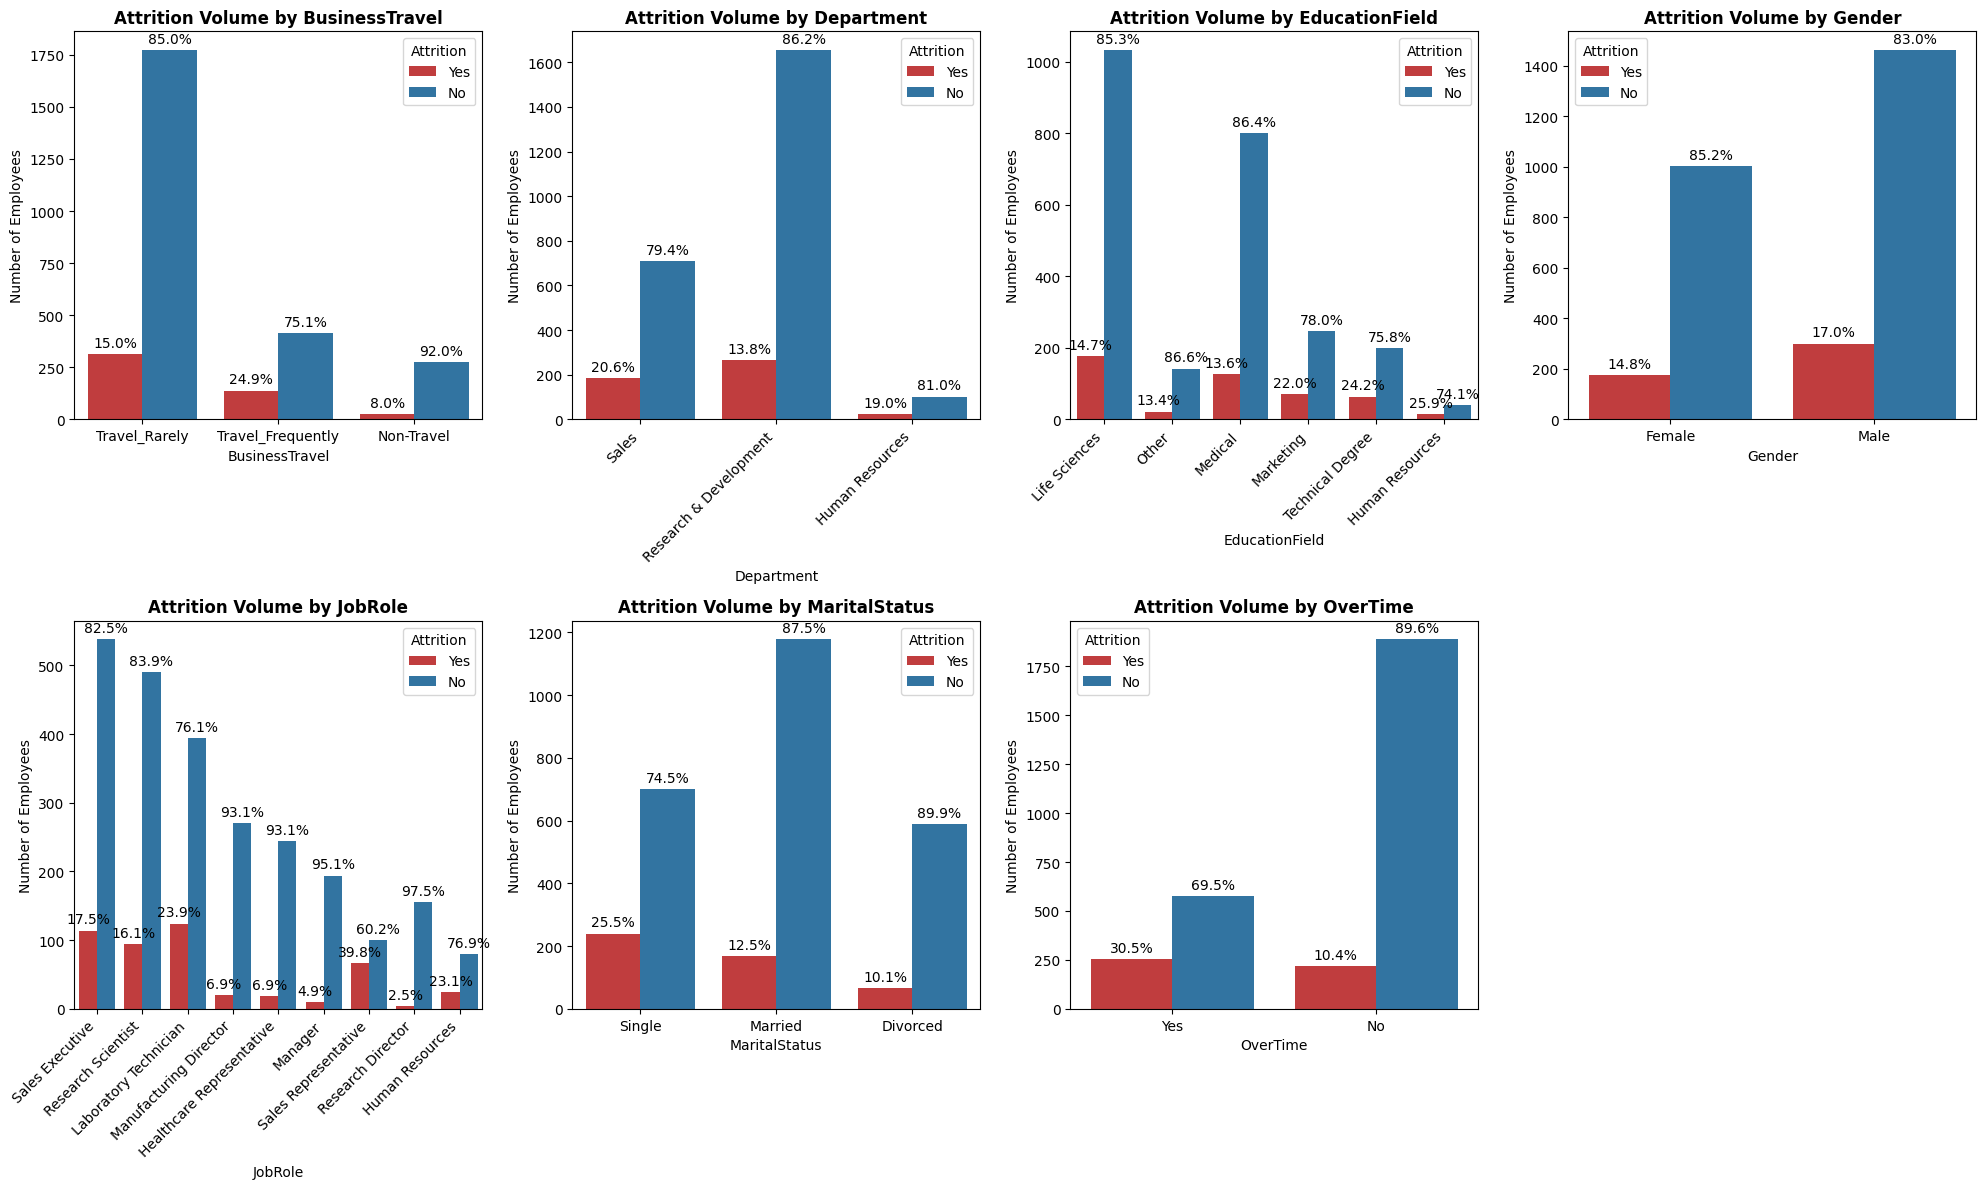

In [ ]:
# Define all categorical columns and exclude 'Attrition'
categorical_cols = attrition.select_dtypes(include=['object', 'category']).columns
categorical_cols = [col for col in categorical_cols if col != 'Attrition']

# Set up the matplotlib figure
plt.figure(figsize=(20, 12))

attrition_colors = {'Yes': '#d62728', 'No': '#1f77b4'}

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 4, i)

    # Save the plot to 'ax'
    ax = sns.countplot(
        data=attrition_df,
        x=col,
        hue='Attrition',
        palette=attrition_colors
    )

    # Calculate within-group percentages
    group_totals = {}
    for p in ax.patches:
        tick_position = int(round(p.get_x() + p.get_width() / 2.0))
        if not pd.isna(p.get_height()):
            group_totals[tick_position] = group_totals.get(tick_position, 0) + p.get_height()

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            tick_position = int(round(p.get_x() + p.get_width() / 2.0))
            local_total = group_totals[tick_position]

            # Calculate the percentage relative to the local group total
            percentage = f'{100 * height / local_total:.1f}%'

            ax.annotate(percentage,
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=10, color='black',
                        xytext=(0, 3),
                        textcoords='offset points')

    # Rotate x-axis labels using a list check
    if col in ['Department', 'EducationField', 'JobRole']:
        plt.xticks(rotation=45, ha='right')

    plt.title(f'Attrition Volume by {col}', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Employees')

plt.tight_layout()
plt.show()

Observations
*   'BusinessTravel': High proportion of employees who travelled frequently attrited, followed by employees who travelled rarely then employees who do not need to travel for work.

*   'JobRole': The amount and proportion of employee attrition varies a lot among the different job roles. A very high proportion of Sales Representative attrited. On the other hand, Research Director showed very low attrition.

*   'MaritalStatus': Majority of the attrited employees were single. There was also higher proportion of employees who attrited in the 'Single' group as compared to 'Married' and 'Divorced'.

*   'OverTime': Higher proportion who employees who had overtime work attrited as compared to those without overtime work.

*   'Department' and 'EducationField': No obvious trends observed.



**Correlation Heatmap**

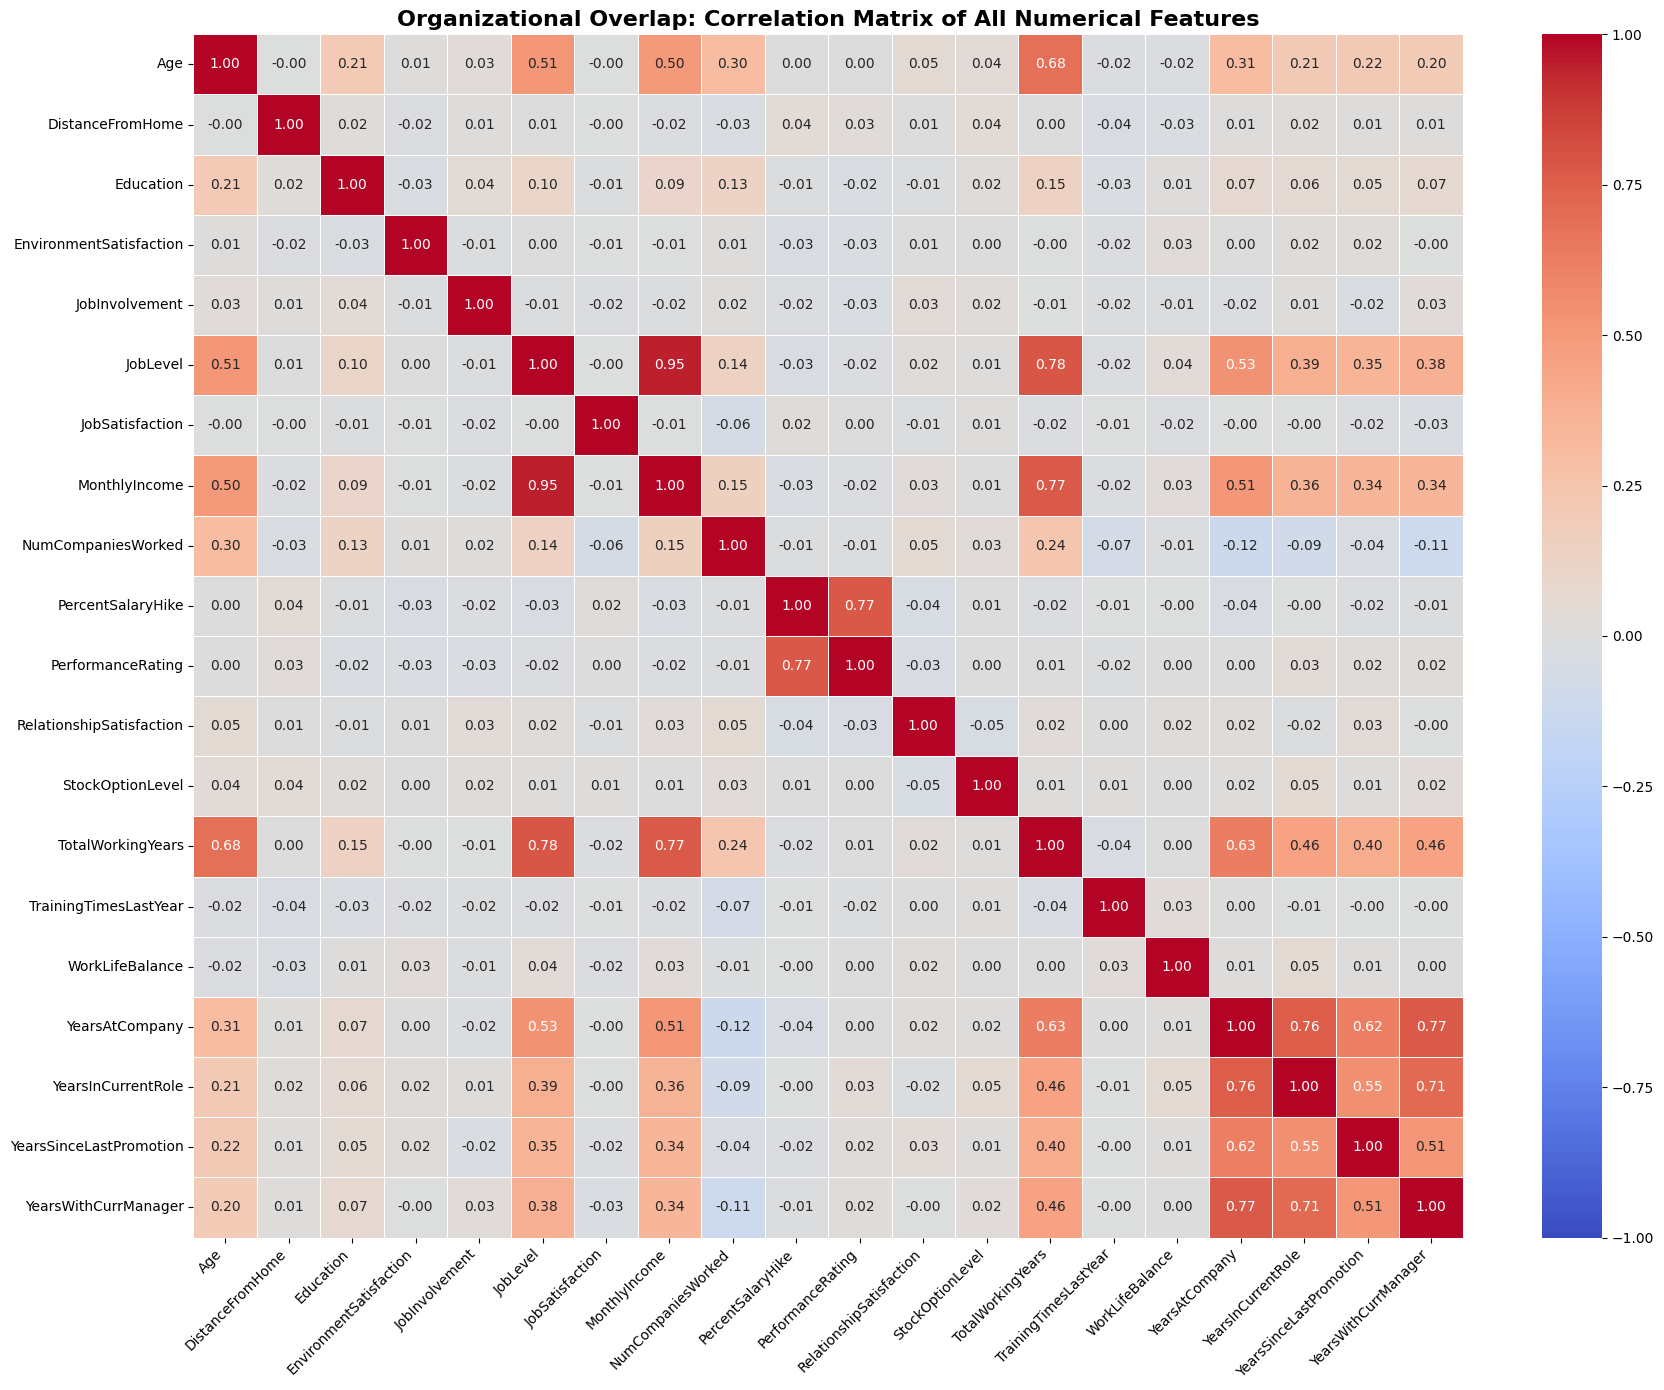

In [ ]:
# Set up the matplotlib figure
plt.figure(figsize=(18, 14))

# Select only the numerical columns
numeric_df = attrition.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Organizational Overlap: Correlation Matrix of All Numerical Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

'MonthlyIncome' and 'JobLevel' had a high correlation of 0.95, indicating severe multicollinearity. To resolve this, 'JobLevel' will be removed. 'MonthlyIncome' was retained because it is a continuous variable with much more variance and granularity.

# Feature Selection

**Treat Multicollinearity**

In [ ]:
# Remove JobLevel column
attrition = attrition.drop(columns=['JobLevel'])

print(attrition.shape)

(2940, 27)


# Data Transformation

**Binary & Ordinal Encoding**

In [ ]:
# Map 'Yes' to 1 and 'No' to 0 for 'Attrition'
attrition['Attrition'] = attrition['Attrition'].map({'Yes': 1, 'No': 0})

print("Data type:", attrition['Attrition'].dtype)

Data type: int64


In [ ]:
# Map 'Yes' to 1 and 'No' to 0 for 'OverTime'
attrition['OverTime'] = attrition['OverTime'].map({'Yes': 1, 'No': 0})

print("Data type:", attrition['OverTime'].dtype)

Data type: int64


In [ ]:
# Map 'Non-Travel'to 0, 'Travel_Rarely'to 1 and 'Travel_Frequently' to 2 for 'BusinessTravel'
attrition['BusinessTravel'] = attrition['BusinessTravel'].map({'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2})

print("Data type:", attrition['BusinessTravel'].dtype)

Data type: int64


Binary encoding was applied to 'Attrition' and 'Overtime'. Ordinal encoding was performed on 'BusinessTravel'.

**One-Hot Encoding**

In [ ]:
# Get a list of all column names where the data type is 'object'
object_cols = attrition.select_dtypes(include=['object']).columns.tolist()

print(object_cols)

['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


In [ ]:
# Create a new dataframe 'attrition_encoded' for dataset after one-hot encoding
attrition_encoded = pd.get_dummies(
    data=attrition,
    columns=object_cols,
    drop_first=True,
    dtype=int
)

print(attrition_encoded.shape)

(2940, 40)


One-hot encoding was performed on all categorical features to make them into machine-readable numerical format.

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Define features (x) and target (y)
x = attrition_encoded.drop('Attrition', axis=1)
y = attrition_encoded['Attrition']

# Perform the stratified train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=80, stratify=y)

A train-test split was performed, allocating 80% of the dataset for model training and keeping the remaining 20% for testing.

**Feature Scaling**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
numerical_cols = [
    'Age', 'BusinessTravel', 'DistanceFromHome', 'Education',
    'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction',
    'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
    'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
    'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

# Initialize the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

# Force the output to stay a Pandas DataFrame instead of a Numpy Array
preprocessor.set_output(transform="pandas")

# Fit and transform the training data
x_train_scaled = preprocessor.fit_transform(x_train)

# Transform the test data
x_test_scaled = preprocessor.transform(x_test)

Standardisation was applied on all numerical columns after train-test split. The scaler was trained on x_train only so that it learns the mean and variance of the training data. Scaling was then applied to both x_train and x_test using the learned parameters, ensuring no data leakage.


**Treat Class Imbalance**

In [ ]:
from imblearn.over_sampling import SMOTENC

# Find the indices of categorical columns
categorical_indices = [
    i for i, col in enumerate(x_train_scaled.columns)
    if x_train_scaled[col].nunique() <= 2
]

# Initialize SMOTENC
smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=66)

# Balance the scaled training data
x_train_balanced, y_train_balanced = smote_nc.fit_resample(x_train_scaled, y_train)

# Check the new class distribution
print("Before SMOTENC:")
print(y_train.value_counts())
print("\nAfter SMOTENC:")
print(y_train_balanced.value_counts())

Before SMOTENC:
Attrition
0    1973
1     379
Name: count, dtype: int64

After SMOTENC:
Attrition
0    1973
1    1973
Name: count, dtype: int64


To address the issue of class imbalance, SMOTENC was applied on the training set to balance the data, ensuring there were equal number of entries for employees who attrited and retained. SMOTENC selected as it can effectively handle both numerical and categorical features.

# Modelling

**Model Selection**

The objective for the modelling is to identify the features strongly associated with employee attrition. Therefore, only algorithms capable of generating feature importance scores or interpretable coefficients were utilised. The selected algorithms for this task were Logistic Regression, Decision Tree and Random Forest.

**Hyperparameter Tuning**

An automated hyperparameter tuning pipeline was constructed to evaluate the 3 algorithms to find the optimal configuration that gives the best performance.

The GridSearchCV module was used to perform thorough hyperparameter tuning. It applied 5-fold cross-validation across the training set to evaluate different parameter combinations without overfitting.

After the best model for each algorithm were generated, the models were compared using accuracy, precision, recall and F1 score. F1 score was chosen as the primary performance indicator as it combines precision and recall into one metric using their harmonic mean. This ensures that the model maintains a balance between correctly identifying employees who are likely to leave and minimising false predictions. The overall best performing model was used to generate the feature importance scores for evaluation.

In [ ]:
# Import Libraries
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

seed = 80

In [ ]:
# Define dictionary for modelling
model_params = {
    'Logistic Regression': {
        'model': LogisticRegression(solver='liblinear', random_state=seed),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=seed),
        'params': {
            'max_depth': [5, 10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=seed, n_jobs=-1),
        'params': {
            'n_estimators': [100, 300, 500],
            'max_depth': [10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    }
}

# Initialise empty lists for metrics
names = []
scores = []
precisions = []
recalls = []
f1_scores = []
best_parameters = []

# Loop through the dictionary using GridSearchCV
for name, mp in model_params.items():

    # Initialize the GridSearchCV for thorough tuning
    grid = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='accuracy', n_jobs=-1)

    # Train the grid on the balanced data
    grid.fit(x_train_balanced, y_train_balanced)

    # Extract the absolute best model found by the grid
    best_model = grid.best_estimator_

    # Make predictions on the unseen scaled test data using the best model
    y_pred = best_model.predict(x_test_scaled)

    # Calculate all metrics and append them
    names.append(name)
    scores.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, pos_label=1))
    f1_scores.append(f1_score(y_test, y_pred, pos_label=1))
    best_parameters.append(grid.best_params_)

# Add the lists to the final DataFrame
models_comparison = pd.DataFrame({
    'Name': names,
    'Score': scores,
    'Precision': precisions,
    'Recall': recalls,
    'F1_Score': f1_scores,
    'Best_Params': best_parameters
})

# Sort the dataframe by F1-Score and display
models_comparison.sort_values(by='F1_Score', ascending=False, inplace=True)
pd.set_option('display.max_colwidth', None)
print(models_comparison)

                  Name     Score  Precision    Recall  F1_Score  \
2        Random Forest  0.981293   0.956522  0.926316  0.941176   
1        Decision Tree  0.962585   0.876289  0.894737  0.885417   
0  Logistic Regression  0.809524   0.441379  0.673684  0.533333   

                                                                             Best_Params  
2  {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}  
1                       {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}  
0                                                            {'C': 100, 'penalty': 'l2'}  


Random Forest is the best performing model. It has the highest F1 score of 0.941, while also achieving the highest precision (95.7%) and recall (92.6%) as compared to the other 2 models.

The Random Forest model is able to identify true attrition risks (high recall) while minimising false alarms (high precision), making its generated feature importance scores highly reliable for interpretation.

# Feature Importance

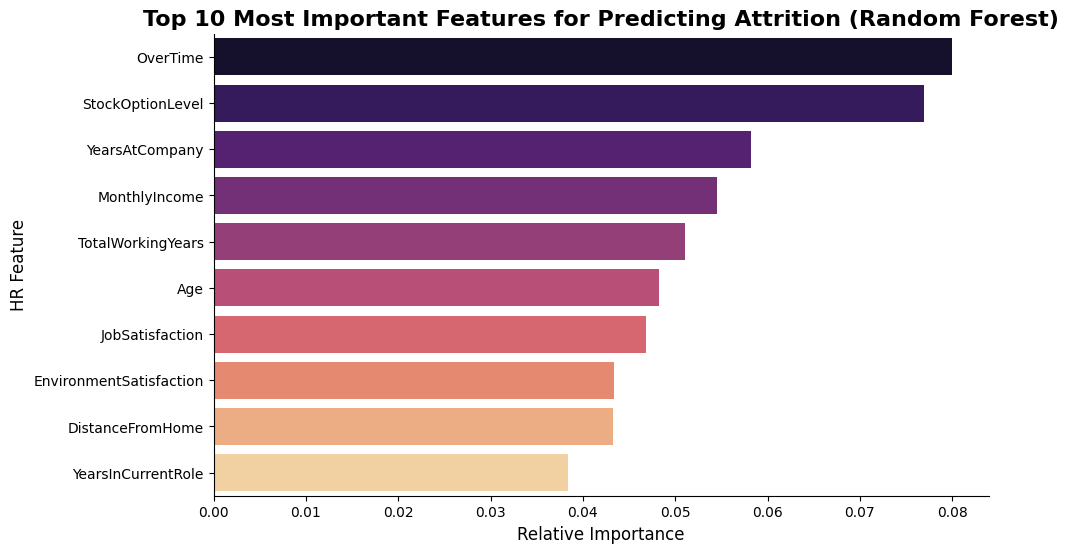

                    Feature  Importance
20                 OverTime    0.079954
12         StockOptionLevel    0.076989
16           YearsAtCompany    0.058231
7             MonthlyIncome    0.054552
13        TotalWorkingYears    0.051079
0                       Age    0.048202
6           JobSatisfaction    0.046886
4   EnvironmentSatisfaction    0.043381
2          DistanceFromHome    0.043271
17       YearsInCurrentRole    0.038388


In [ ]:
# Extract the importance scores from the best model (Random Forest)
importances = best_model.feature_importances_

# Retrieve column names from training data
feature_names = x_train_balanced.columns

# Combine feature names and feature importance into a clean Pandas DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df['Feature'] = feature_importance_df['Feature'].str.split('__').str[-1]

# Sort the dataframe from most to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 10 features
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    legend=False,
    palette='magma'
)

plt.title('Top 10 Most Important Features for Predicting Attrition (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('HR Feature', fontsize=12)

sns.despine()
plt.show()

# Print relative importance below the chart
print(feature_importance_df.head(10))

'OverTime' was the strongest predictor of employee attrition in the Random Forest model. It was followed by 'StockOptionLevel' and 'YearsAtCompany'.

The 10 most important features were distributed across different categories:
*   Employee Demographics & Background: 'Age', 'DistanceFromHome'
*   Role & Work Conditions: 'OverTime'
*   Compensation & Benefits: 'StockOptionLevel', 'MonthlyIncome'
*   Tenure & Career History: 'YearsAtCompany', 'TotalWorkingYears', 'YearsInCurrentRole'
*   Satisfaction & Performance: 'JobSatisfaction', 'EnvironmentSatisfaction'

The importance values were relatively low and close to each other which suggested that there was no extremely strong association between any feature and attrition. Instead, attrition is the result of a cumulative combination of factors.

# Recommendations

Based on the exploratory data analysis done earlier, some recommendations could be given to HR for their consideration.




**Strengthen Overtime Management**

Since overtime is strongly associated with attrition, HR could first review workload distribution, overtime requirements and staffing levels. HR should also implement an alert system to track employees who consistently work overtime. If any employee is flagged, HR can request the department manager to justify for the overtime and explore redistribution of workload. Additionally, HR should review the current overtime compensation schemes to ensure they remain fair and competitive.

**Review Stock Options Policy**

Exploration data analysis revealed that employees with no stock options had a higher observed attrition rate compared with employees receiving any level of stock options. HR should review the current stock option allocation policy and evaluate whether eligibility criteria could be adjusted to provide some employees currently without stock options with Level 1 stock options as part of their employee retention strategy.

**Improve Employee Development**

Features like 'YearsAtCompany',  'TotalWorkingYears', 'Age' and 'YearsInCurrentRole' indicate that employees who leave are typically younger and have less tenure than those who remain. HR should implement longer-term mentorship programs that outline clear career progression and growth paths, assuring newer employees of their career development within the company. HR could also implement job rotation or cross-training programs to prevent role fatigue or stagnation.

HR should go through the list of features that are strong predictors of attrition and develop new retention strategies. However, they should understand that the model identified the characteristics that are strong predictors of employee attrition and not strong drivers. It does not mean that these predictors directly cause employees to leave. Further investigations are required before implementing policies based on individual predictors.